In [1]:
!pip install rpy2
!pip install nbconvert

In [4]:
import sqlite3
import pandas as pd
import numpy as np
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri

# Database creation and SQL manipulation

print("1. [PYTHON] Initializing SQLite Database...")
conn = sqlite3.connect('covid_data.db')
cursor = conn.cursor()

print("2. [PYTHON] Loading CSV and writing to SQL...")
raw_df = pd.read_csv('us_counties_covid19_daily.csv')
raw_df.to_sql('daily_reports', conn, if_exists='replace', index=False)

cursor.execute("DELETE FROM daily_reports WHERE fips IS NULL")
conn.commit()

print("3. [PYTHON] Extracting clean data via SQL query...")
query = "SELECT date, county, state, cases, deaths FROM daily_reports ORDER BY date ASC"
df = pd.read_sql_query(query, conn)
conn.close()

# Pass data from python to R with @rpy2@ so we can use @ggplot2@

print("4. [BRIDGE] Passing Pandas DataFrame into R environment...")
pandas2ri.activate()
ro.globalenv['r_df'] = df

# Data Wrangling -  With @ggplot2@

print("5. [R] Executing ggplot2 visualization scripts...")

# The following is the R code that will be passed back to python
r_script = """
# Load required R libraries
suppressMessages(library(ggplot2))
suppressMessages(library(dplyr))
suppressMessages(library(scales))
suppressWarnings(install.packages("zoo", repos = "http://cran.us.r-project.org"))
suppressMessages(library(zoo))

# Convert date string to Date object in R
r_df$date <- as.Date(r_df$date)

# Plot 1: National Cumulative Cases and Deaths (Log Scale)

national_cumulative <- r_df %>%
  group_by(date) %>%
  summarise(total_cases = sum(cases, na.rm = TRUE),
            total_deaths = sum(deaths, na.rm = TRUE), .groups = "drop")

p1 <- ggplot(national_cumulative, aes(x = date)) +
  geom_line(aes(y = total_cases, color = "Cases"), size = 1.2) +
  geom_line(aes(y = total_deaths, color = "Deaths"), size = 1.2) +
  scale_y_log10(labels = comma) +
  scale_color_manual(values = c("Cases" = "blue", "Deaths" = "red")) +
  theme_minimal() +
  labs(title = "Total US Cumulative COVID-19 Cases and Deaths (Log Scale)",
       x = "Date", y = "Count", color = "Metric")

ggsave("01_national_cumulative_ggplot.png", plot = p1, width = 10, height = 6, dpi = 150)

# Plot 2: Daily New Cases (7-Day Rolling Average)

national_daily <- national_cumulative %>%
  mutate(
    new_cases = total_cases - lag(total_cases, default = 0),
    new_cases = ifelse(new_cases < 0, 0, new_cases),
    new_cases_7d_avg = rollmean(new_cases, k = 7, fill = NA, align = "right")
  )

p2 <- ggplot(national_daily, aes(x = date)) +
  geom_col(aes(y = new_cases), fill = "lightblue", alpha = 0.7) +
  geom_line(aes(y = new_cases_7d_avg), color = "navy", size = 1.2) +
  scale_y_continuous(labels = comma) +
  theme_minimal() +
  labs(title = "Daily New COVID-19 Cases in the US",
       subtitle = "Bars = Daily Cases | Line = 7-Day Rolling Average",
       x = "Date", y = "New Cases")

ggsave("02_national_daily_cases_ggplot.png", plot = p2, width = 10, height = 6, dpi = 150)

# Plot 3: Top 16 US Counties with the Most New Cases (7-Day Rolling Average)

# Find top 16 counties
top_16 <- r_df %>%
  filter(date == max(date)) %>%
  mutate(county_state = paste(county, state, sep = ", ")) %>%
  arrange(desc(cases)) %>%
  slice_head(n = 16) %>%
  pull(county_state)

facet_data <- r_df %>%
  mutate(county_state = paste(county, state, sep = ", ")) %>%
  filter(county_state %in% top_16) %>%
  arrange(county_state, date) %>%
  group_by(county_state) %>%
  mutate(
    new_cases = cases - lag(cases, default = 0),
    new_cases = ifelse(new_cases < 0, 0, new_cases),
    new_cases_7d = rollmean(new_cases, k = 7, fill = NA, align = "right")
  ) %>%
  ungroup()

p3 <- ggplot(facet_data, aes(x = date, y = new_cases_7d)) +
  geom_line(color = "firebrick", size = 1) +
  geom_area(fill = "firebrick", alpha = 0.3) +
  facet_wrap(~ county_state, ncol = 4, scales = "free_y") +
  scale_x_date(date_breaks = "3 months", date_labels = "%b") +
  scale_y_continuous(labels = label_number(scale_cut = cut_short_scale())) +
  theme_bw() +
  labs(title = "Daily New Cases in the Top 16 US Counties",
       subtitle = "7-Day Rolling Average (Independent Y-Axes)",
       x = "", y = "") +
  theme(strip.background = element_rect(fill = "grey90"),
        strip.text = element_text(face = "bold"),
        axis.text.x = element_text(angle = 45, hjust = 1))

ggsave("03_county_small_multiples_ggplot.png", plot = p3, width = 12, height = 8, dpi = 150)
"""

ro.r(r_script)

print("6. Pipeline Complete! ggplot2 images saved to the directory.")

1. [PYTHON] Initializing SQLite Database...
2. [PYTHON] Loading CSV and writing to SQL...
3. [PYTHON] Extracting clean data via SQL query...
4. [BRIDGE] Passing Pandas DataFrame into R environment...


(as ‘lib’ is unspecified)



5. [R] Executing ggplot2 visualization scripts...








	‘/tmp/Rtmpinbaio/downloaded_packages’


ℹ Please use `linewidth` instead.
This warning is displayed once per session.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 

 

(`geom_line()`). 


(`geom_line()`). 



6. Pipeline Complete! ggplot2 images saved to the directory.


In [6]:
%load_ext rpy2.ipython

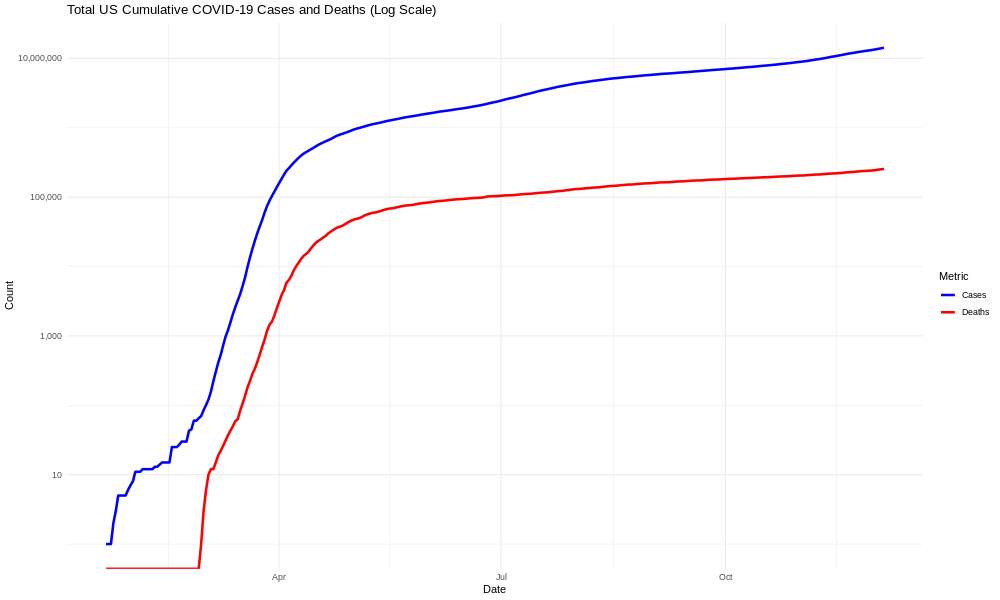

In [7]:
%%R -i df -w 1000 -h 600
install.packages(c("ggplot2", "dplyr", "scales", "zoo"), quiet=TRUE)

suppressMessages(library(ggplot2))
suppressMessages(library(dplyr))
suppressMessages(library(zoo))
suppressMessages(library(scales))

df$date <- as.Date(df$date)

# Calculate National Cumulative Data
national_cumulative <- df %>%
  group_by(date) %>%
  summarise(total_cases = sum(cases, na.rm = TRUE),
            total_deaths = sum(deaths, na.rm = TRUE), .groups = "drop")

# Generate the plot
ggplot(national_cumulative, aes(x = date)) +
  geom_line(aes(y = total_cases, color = "Cases"), size = 1.2) +
  geom_line(aes(y = total_deaths, color = "Deaths"), size = 1.2) +
  scale_y_log10(labels = comma) +
  scale_color_manual(values = c("Cases" = "blue", "Deaths" = "red")) +
  theme_minimal() +
  labs(title = "Total US Cumulative COVID-19 Cases and Deaths (Log Scale)",
       x = "Date", y = "Count", color = "Metric")
